In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
from matplotlib.image import imread

#### Setup artifacts
#####  Download model from https://github.com/quic/aimet-model-zoo/blob/develop/aimet_zoo_torch/quicksrnet/QuickSRNet.md

In [3]:
image_name = "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\input.jpg"
input_image = cv2.imread(image_name)
print(input_image.shape)
input_image_resize = cv2.resize(input_image,(1280,720))
print(input_image_resize.shape)
input_image_clip = np.clip(input_image_resize, 0, 255) 
input_image_clip_norm = input_image_clip / 255.0
input_image_clip_norm.astype(np.float32).tofile("assets\input.raw")


(720, 1280, 3)
(720, 1280, 3)


In [4]:
with open("assets/input_list.txt","w") as file:
    for raw in os.listdir("assets/"):
        if "input.raw" in raw:
            file.write(raw)

In [5]:
os.environ['QNN_ROOT']="C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"
os.environ['PYTHONPATH']= "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\lib\\python"
os.environ['PATH']=os.environ['PATH']+"C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401\\bin\\aarch64-windows-msvc"

In [6]:
import shutil
SDK_dir = "C:\\Qualcomm\\AIStack\\QAIRT\\2.21.0.240401"
SDK_lib_dir = SDK_dir + "\\lib\\arm64x-windows-msvc"
SDK_skel = SDK_dir + "\\lib\\hexagon-v73\\unsigned"

# Copy necessary libraries to a common location
libs = ["QnnCpu.dll","QnnHtp.dll", "QnnSystem.dll", "QnnHtpNetRunExtensions.dll", "QnnHtpPrepare.dll", "QnnHtpV73Stub.dll"]
for lib in libs:
    shutil.copy(SDK_lib_dir + "\\" + lib, "assets")
skel_libs = ["libqnnhtpv73.cat", "libQnnHtpV73.so", "libQnnHtpV73Skel.so"]
# Copy Skel
for lib in skel_libs:
    shutil.copy(SDK_skel + "\\" + lib, "assets")

In [7]:

%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\quicksrnet_large.onnx" -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.cpp"  --act_quantizer enhanced 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\quicksrnet_large.onnx" -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.cpp"  --act_quantizer enhanced 


2024-06-15 02:05:16,684 - 240 - WARNING - WARNING_OPSET_VERSION: Warning multiple opset versions specified, using highest.
2024-06-15 02:05:16,955 - 235 - INFO - Skipping quantization, no input_list provided
2024-06-15 02:05:16,955 - 235 - INFO - Saving QNN Model...
2024-06-15 02:05:16,955 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.cpp 
2024-06-15 02:05:16,955 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\super_resolution\assets\float32\qsrnet_large.bin 
2024-06-15 02:05:16,962 - 235 - INFO - Conversion complete!



C:\Qualcomm\AIStack\models\super_resolution\assets>

In [ ]:
'''
[NOT TESTED]
If you want to convert the model to int16 instead of int8, please use the following command in the cell below: 
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" ^
    -i "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\quicksrnet_large.onnx" ^
    --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.cpp" ^
    --act_bw 16 --weight_bw 16 --bias_bw 8
'''

In [20]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\quicksrnet_large.onnx" --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.cpp" 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-onnx-converter" -i "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\quicksrnet_large.onnx" --input_list input_list.txt -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.cpp" 


2024-06-15 02:09:34,201 - 240 - WARNING - WARNING_OPSET_VERSION: Warning multiple opset versions specified, using highest.
2024-06-15 02:09:43,636 - 235 - INFO - Saving QNN Model...
2024-06-15 02:09:43,636 - 235 - INFO - Model CPP saved at: C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.cpp 
2024-06-15 02:09:43,643 - 235 - INFO - Model BIN saved at: C:\Qualcomm\AIStack\models\super_resolution\assets\int8\qsrnet_large.bin 
2024-06-15 02:09:43,643 - 235 - INFO - Conversion complete!


     0.2ms [  INFO ] Inferences will run in sync mode
     0.4ms [  INFO ] Initializing logging in the backend. Callback: [00007FFDBDBD7810], Log Level: [3]
     0.4ms [  INFO ] No BackendExtensions lib provided;initializing NetRunBackend Interface
     0.5ms [WARNING] Unable to find a device with NetRunDeviceKeyDefault in Library NetRunBackendLibKeyDefault
     0.7ms [  INFO ] Entering QuantizeRuntimeApp flow
     4.4ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::finalize
   150.5ms [  INFO ] CpuGraph::qnn::cpu::CpuGraph::execute
  9087.1ms [  INFO ] cleaning up resources for input tensors
  9087.6ms [  INFO ] cleaning up resources for output tensors
  9177.9ms [  INFO ] Freeing graphsInfo

C:\Qualcomm\AIStack\models\super_resolution\assets>

In [21]:
%%cmd
cd assets
mkdir "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs"
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.cpp" -b "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.bin" -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\float32\\" -t windows-aarch64

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>mkdir "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs"



A subdirectory or file C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs already exists.


C:\Qualcomm\AIStack\models\super_resolution\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.cpp" -b "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.bin" -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\float32\\" -t windows-aarch64


2024-06-15 02:09:43,879 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.cpp
2024-06-15 02:09:43,879 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\float32\\qsrnet_large.bin
2024-06-15 02:09:43,879 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-15 02:09:43,879 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-15 02:09:43,879 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\float32\
2024-06-15 02:09:43,879 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-15 02:09:43,879 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-15 02:09:43,879 -    INFO - qnn-model-lib-generator: Output library name  : qsrnet_large.dll
2024-06-15 02:09:43,918 -   


C:\Qualcomm\AIStack\models\super_resolution\assets>

In [10]:
%%cmd
cd assets
python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.cpp" -b "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.bin" -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\int8\\" -t windows-aarch64 

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>python "C:\Qualcomm\AIStack\QAIRT\\2.21.0.240401\bin\arm64x-windows-msvc\qnn-model-lib-generator" -c "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.cpp" -b "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.bin" -o "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\int8\\" -t windows-aarch64 


2024-06-15 02:06:04,340 -    INFO - qnn-model-lib-generator: Model cpp file path  : C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.cpp
2024-06-15 02:06:04,340 -    INFO - qnn-model-lib-generator: Model bin file path  : C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\int8\\qsrnet_large.bin
2024-06-15 02:06:04,340 -    INFO - qnn-model-lib-generator: Library target       : ['windows-aarch64']
2024-06-15 02:06:04,340 -    INFO - qnn-model-lib-generator: Library name         : None
2024-06-15 02:06:04,340 -    INFO - qnn-model-lib-generator: Output directory     : C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\int8\
2024-06-15 02:06:04,340 -    INFO - qnn-model-lib-generator: Build type           : Release
2024-06-15 02:06:04,340 -    INFO - qnn-model-lib-generator: Clean-up             : False
2024-06-15 02:06:04,340 -    INFO - qnn-model-lib-generator: Output library name  : qsrnet_large.dll
2024-06-15 02:06:04,382 -    INFO - q


C:\Qualcomm\AIStack\models\super_resolution\assets>

In [11]:
json_str = """{
    "graphs": {
        "vtcm_mb":8,
        "graph_names":[],
        "O":3.0
    },
    "devices": [
        {
            "soc_id": 60,
            "dsp_arch": "v73",
            "cores":[{
                "core_id": 0,
                "perf_profile": "burst",
                "rpc_control_latency":100
            }]
        }
    ]
}"""
f = open("./assets/htp_backend_extensions.json", "w")
f.write(json_str)
f.close()

In [12]:
%%cmd
cd assets
qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\int8\ARM64\qsrnet_large.dll"  --backend "QnnHtp.dll" --binary_file qsrnet_large.serialized --config_file "htp_backend_extensions.json"
move  output\qsrnet_large.serialized.bin "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\qsrnet_large.serialized.v73.bin"

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>qnn-context-binary-generator --model "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\int8\ARM64\qsrnet_large.dll"  --backend "QnnHtp.dll" --binary_file qsrnet_large.serialized
qnn-context-binary-generator pid:18104
Starting stage: Graph Preparation Initializing
Completed stage: Graph Preparation Initializing (214 us)
Starting stage: Graph Transformations and Optimizations
Completed stage: Graph Transformations and Optimizations (406581 us)
Starting stage: Graph Sequencing for Target
 [##################################################] 100%
Completed stage: Graph Sequencing for Target (148773 us)
Starting stage: VTCM Allocation
Completed stage: VTCM Allocation (138033 us)
Starting stage: Parallelization Optimization
Completed stage: Parallelization Optimization (6977 u

In [13]:
%%cmd 
cd assets
rmdir /s  output_cpu
Y
rmdir /s  output_dsp 
Y

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.



The system cannot find the file specified.


C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>rmdir /s  output_cpu
output_cpu, Are you sure (Y/N)? Y

C:\Qualcomm\AIStack\models\super_resolution\assets>rmdir /s  output_dsp 
output_dsp, Are you sure (Y/N)? Y


The system cannot find the file specified.



C:\Qualcomm\AIStack\models\super_resolution\assets>

In [14]:
%%cmd
cd assets
qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\float32\ARM64\qsrnet_large.dll" --input_list input_list.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>qnn-net-run --model "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\model_libs\\float32\ARM64\qsrnet_large.dll" --input_list input_list.txt --backend QnnCpu.dll --output_dir output_cpu --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:3732

C:\Qualcomm\AIStack\models\super_resolution\assets>

In [15]:
%%cmd
cd assets
qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\qsrnet_large.serialized.v73.bin" --input_list input_list.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic

Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>qnn-net-run --retrieve_context "C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\qsrnet_large.serialized.v73.bin" --input_list input_list.txt --backend QnnHtp.dll --output_dir output_dsp --perf_profile sustained_high_performance  --profiling_level basic
qnn-net-run pid:21080
     0.0ms [WARNING] QnnDsp <W> Function not called, PrepareLib isn't loaded!


C:\Qualcomm\AIStack\models\super_resolution\assets>

In [16]:
def crop_image(img, xy, scale_factor):
    '''Crop the image around the tuple xy

    Inputs:
    -------
    img: Image opened with PIL.Image
    xy: tuple with relative (x,y) position of the center of the cropped image
        x and y shall be between 0 and 1
    scale_factor: the ratio between the original image's size and the cropped image's size
    '''
    center = (img.size[0] * xy[0], img.size[1] * xy[1])
    new_size = (img.size[0] / scale_factor, img.size[1] / scale_factor)
    left = max (0, (int) (center[0] - new_size[0] / 2))
    right = min (img.size[0], (int) (center[0] + new_size[0] / 2))
    upper = max (0, (int) (center[1] - new_size[1] / 2))
    lower = min (img.size[1], (int) (center[1] + new_size[1] / 2))
    cropped_img = img.crop((left, upper, right, lower))
    return cropped_img

In [17]:
from PIL import Image
def postprocess(path):
    
    plt.figure(dpi=100)
    
    #subplot(r,c) provide the no. of rows and columns
    f, axarr = plt.subplots(nrows=3,ncols=3,figsize=(20,20)) 
    
    results = []
    for id,OUTPUT in enumerate(path):
        for id,result in enumerate(os.listdir(OUTPUT)):
            if "log" not in result:
                for raw in ["_124.raw"]:
                    x = np.fromfile(OUTPUT+result+"/"+raw,dtype="float32").reshape(2160,3840,3)
                    x = x * 255
                    x = cv2.cvtColor(x, cv2.COLOR_RGB2BGR) 
                    x = x.astype(int)
                    x = np.clip(x,0,255).astype(np.uint8)
                    results.append(x)
    inp = cv2.imread("C:\\Qualcomm\\AIStack\\models\\super_resolution\\assets\\input.jpg")
    inp = cv2.resize(inp,(3840,2160))
    inp = cv2.cvtColor(inp, cv2.COLOR_RGB2BGR) 

    axarr[0,0].imshow(inp)
    axarr[0,1].imshow(results[0])
    axarr[0,2].imshow(results[1])
    axarr[1,0].imshow(crop_image(Image.fromarray(inp), (0.60, 0.50), 3.0))
    axarr[1,1].imshow(crop_image(Image.fromarray(results[1]), (0.60, 0.50), 3.0))
    axarr[2,0].imshow(crop_image(Image.fromarray(inp), (0.50, 0.50), 6.0))
    axarr[2,1].imshow(crop_image(Image.fromarray(results[1]), (0.50, 0.50), 6.0))
    
    
    axarr[0,0].title.set_text('Input image')
    axarr[0,1].title.set_text('CPU')
    axarr[0,2].title.set_text('HTP')
    axarr[1,0].title.set_text('zoom input')
    axarr[1,1].title.set_text('zoom HTP')
    axarr[2,0].title.set_text('zoom input')
    axarr[2,1].title.set_text('zoom HTP')
    f.delaxes(axarr[1][2])
    f.delaxes(axarr[2][2])


<Figure size 640x480 with 0 Axes>

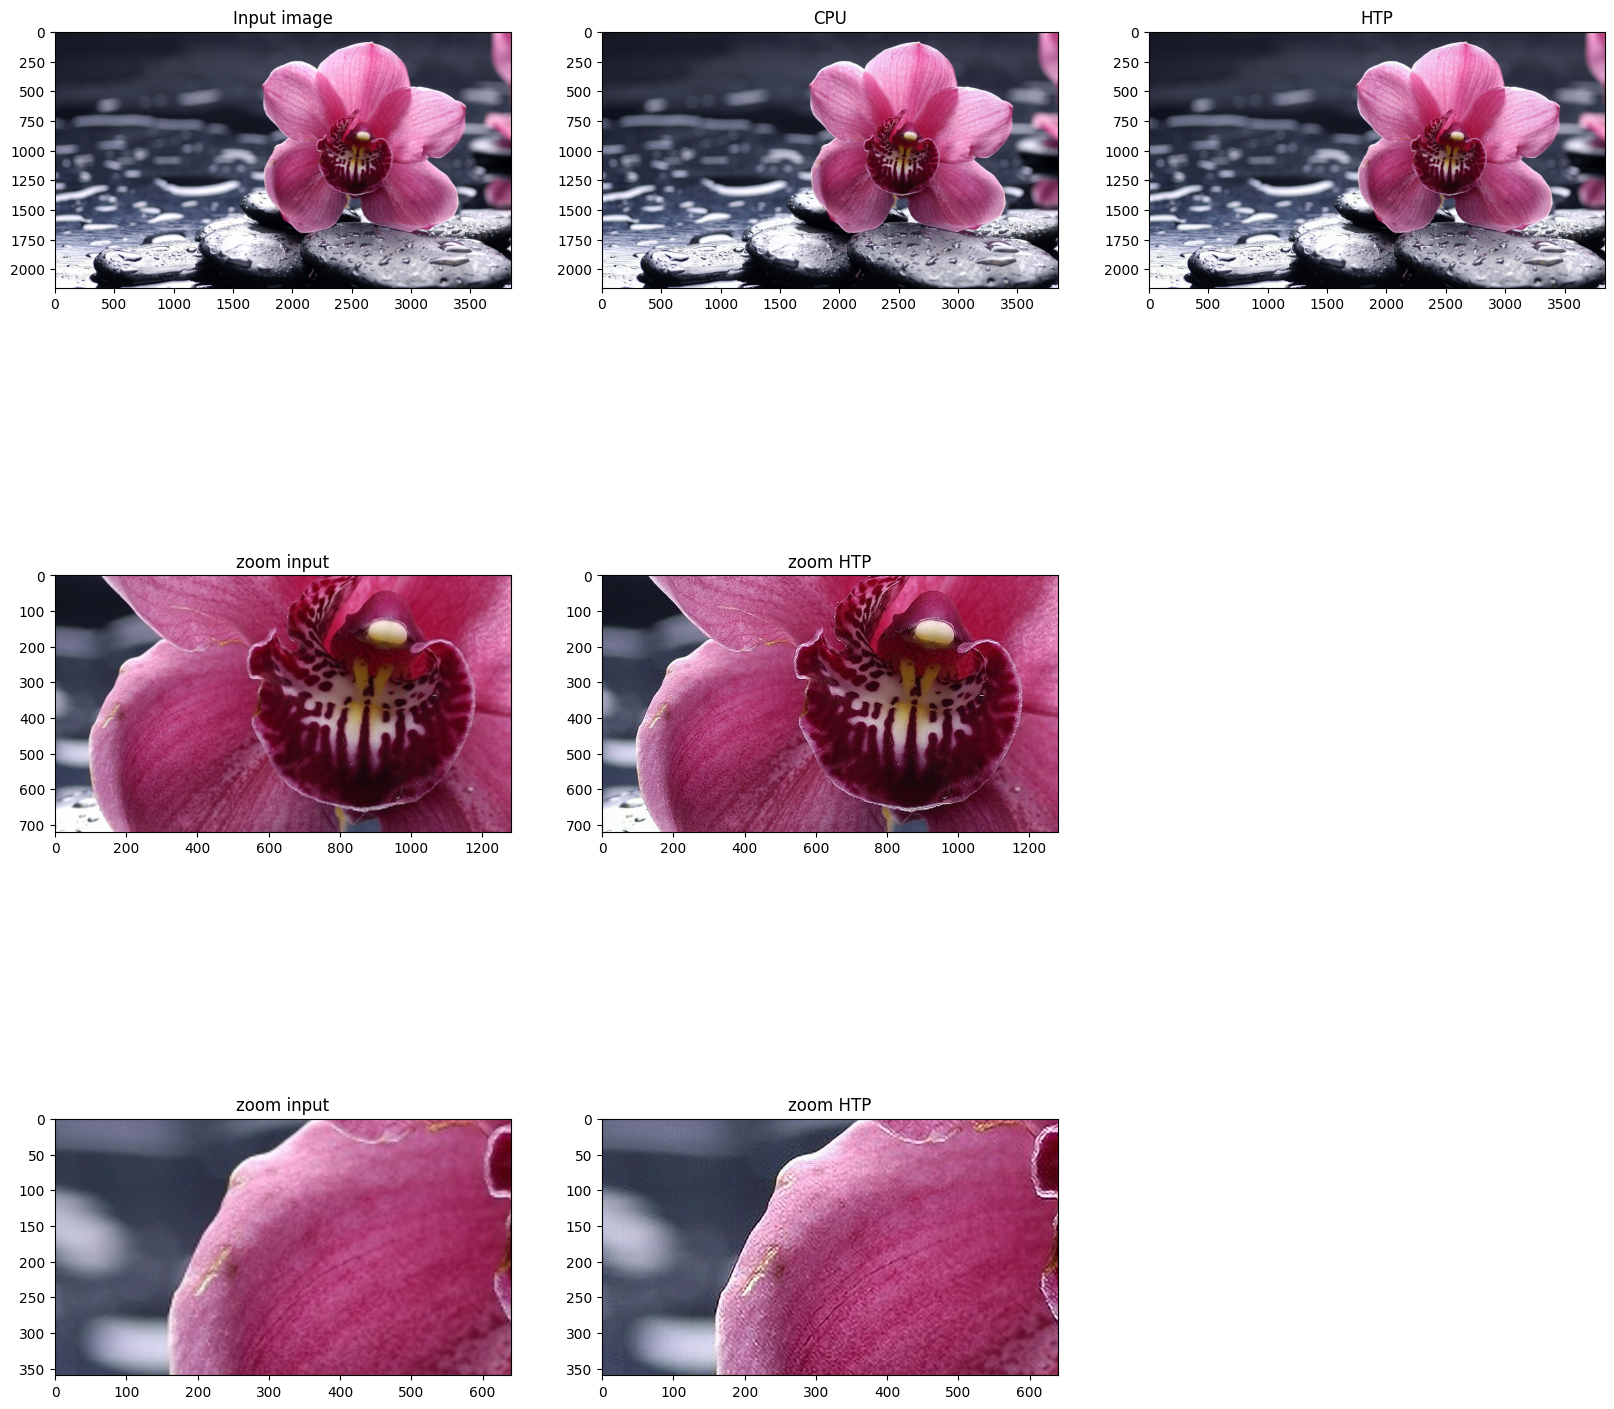

In [18]:
postprocess(["assets/output_cpu/","assets/output_dsp/"])

In [19]:
%%cmd
cd assets
qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log


Microsoft Windows [Version 10.0.26052.1000]
(c) Microsoft Corporation. All rights reserved.

C:\Qualcomm\AIStack\models\super_resolution>cd assets

C:\Qualcomm\AIStack\models\super_resolution\assets>qnn-profile-viewer --input_log output_dsp/qnn-profiling-data_0.log
Log File Created: Sat Jun 15 02:06:34 2024
Time Scale: 1e-06
Epoch Timestamp: 1718442394454374 Steady Clock Timestamp: 915401808296
Generated using: 
qnn-profile-viewer v2.21.0.240401120655_85612
qnn-net-run        v2.21.0.240401120655_85612
Backend            v2.21.0.240401120655_85612

Qnn Init/Prepare/Finalize/De-Init/Execute/Lib-Load Statistics:
------------------------------------------------------------
Init Stats:
-----------
    NetRun: 36307 us
    Backend (RPC (load binary) time): 26461 us
    Backend (QNN accelerator (load binary) time): 25999 us
    Backend (Accelerator (load binary) time): 25714 us
    Backend (QNN (load binary) time): 36292 us

Compose Graphs Stats:
--------------
    NetRun: 0 us

Finalize Sta